# Introduction

This notebook presents the final stage of the analytical framework by transforming the results of the previous analyses into practical insights and decision-oriented recommendations.

Building on the exploratory analyses conducted at both the activity and project levels, the objective is to identify the dimensions and patterns that appear most relevant for interpreting project-level evaluation outcomes and to translate these findings into illustrative recommendations for program evaluation and management. Rather than focusing on individual model results, this notebook synthesizes evidence from the different analytical stages to provide an integrated interpretation of the framework.

The recommendations consider both the relative importance of the evaluation dimensions and the strength of the supporting evidence, recognizing that not all findings are supported with the same level of credibility. This approach helps prioritize potential improvement areas while acknowledging the limitations of the current synthetic dataset.

Because this research represents a methodological validation of a synthetic decision-support framework, the insights presented here should be interpreted as illustrative rather than prescriptive. They illustrate how the proposed framework can support structured decision making and highlight potential areas for further investigation. As additional real-world data become available, these insights and recommendations can be refined and validated within operational contexts.

## 1-Data Loading and Overview

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")

files = [
    "/kaggle/input/datasets/jfjutras07/data-simulation-dataset/3-Data_Simulation_Dataset.xlsx",
    "/kaggle/input/datasets/jfjutras07/activity-clustering-dataset/7-Activity_Clustering_Dataset.xlsx",
    "/kaggle/input/datasets/jfjutras07/data-project-dataset/6-Data_Project_Dataset.xlsx"
]

dataframes = {}
meta_rows = []

for file_path in files:
    xls = pd.ExcelFile(file_path)
    sheet_names = [s for s in xls.sheet_names if s != "Lists"]
    
    for sheet in sheet_names:
        df = pd.read_excel(xls, sheet_name=sheet)
        
        key = f"{file_path.split('/')[-1].replace('.xlsx','')}__{sheet}"
        dataframes[key] = df
        
        meta_rows.append({
            "dataset": file_path.split('/')[-1],
            "table_name": sheet,
            "n_rows": df.shape[0],
            "n_cols": df.shape[1]
        })

overview = pd.DataFrame(meta_rows)
overview

,dataset,table_name,n_rows,n_cols
0,3-Data_Simulation_Dataset.xlsx,Activity,196,13
1,3-Data_Simulation_Dataset.xlsx,Activity_Agg,50,42
2,3-Data_Simulation_Dataset.xlsx,Activity_Partner,312,2
3,3-Data_Simulation_Dataset.xlsx,Capacity,7,2
4,3-Data_Simulation_Dataset.xlsx,Component,60,3
5,3-Data_Simulation_Dataset.xlsx,Mandate,16,8
6,3-Data_Simulation_Dataset.xlsx,Mandate_Capacity,16,2
7,3-Data_Simulation_Dataset.xlsx,Partner,5,4
8,3-Data_Simulation_Dataset.xlsx,Project,50,71
9,3-Data_Simulation_Dataset.xlsx,Risk,11,5


## 2-Activity-Level Insights

### Activity Cluster Analysis

In a previous step, we applied a clustering approach to group activities based on their cost, time, novelty, and effort dimensions. The results showed limited separation between clusters, with low internal validation scores indicating that some activities shared similar characteristics. Within the simulated dataset, the activity groups can be interpreted as follows:

- Cluster 0 represented activities with consistently lower simulated resource requirements across the evaluated dimensions (60 activities);
- Cluster 1 captured activities associated with higher simulated time requirements and coordination needs, with otherwise moderate complexity levels (48 activities);
- Cluster 2 grouped activities with higher simulated novelty and effort scores, reflecting greater variability and adaptation requirements (34 activities);
- Cluster 3 represented activities with higher simulated cost, time, and effort requirements combined with moderate novelty levels (54 activities).

Although some cost components may not be easily reduced, the analysis suggests that activity design can be further examined, particularly regarding effort, standardization, and the balance between recurring and adaptive activities. 

As an exploratory step, activities with higher novelty and effort scores could be reviewed within projects showing stronger evaluation outcomes to assess whether clear deliverables and appropriate structures are in place. This could help identify potential areas for improving activity planning and consistency across projects. In addition, AI-assisted tools could be explored as a potential option to support efficiency in repetitive activities. However, these opportunities would require validation with real-world data before being considered as operational recommendations.

### Activity Patterns within Higher Aggregated Evaluation Profiles

In [2]:
# Explore whether activity patterns differ among projects
# with higher aggregated evaluation profiles

# Projects with highest aggregated evaluation profiles (Cluster 1-3 activities, with deliverables only)

# Define working DataFrames
df_projects = dataframes["3-Data_Simulation_Dataset__Project"].copy()
df_activities = dataframes["7-Activity_Clustering_Dataset__Activity_Clustering_Dataset"].copy()

# Overall performance score
df_projects["performance_score"] = (
    df_projects[["use_mean", "results_mean", "satisfaction_mean"]]
    .mean(axis=1)
)

# Top 10 projects
top10_projects = (
    df_projects
    .sort_values("performance_score", ascending=False)
    .head(10)
    [[
        "id_project",
        "id_mandate",
        "project_title",
        "project_type",
        "performance_score"
    ]]
    .merge(
        dataframes["3-Data_Simulation_Dataset__Mandate"][
            ["id_mandate", "id_volunteer"]
        ],
        on="id_mandate",
        how="left"
    )
    .merge(
        dataframes["3-Data_Simulation_Dataset__Volunteer"][
            ["id_volunteer", "volunteer_name"]
        ],
        on="id_volunteer",
        how="left"
    )
)

# Keep only deliverable-related activities in Clusters 1-3
activities_filtered = df_activities[
    (df_activities["Cluster"].isin([1, 2, 3])) &
    (df_activities["deliverable_associated"] == "Y")
]

# Merge
project_activity_summary = (
    top10_projects
    .merge(
        activities_filtered[
            [
                "id_project",
                "id_activity",
                "activity_type",
                "deliverable_associated",
                "cost",
                "time",
                "novelty",
                "effort",
                "Cluster"
            ]
        ],
        on="id_project",
        how="inner"
    )
    .sort_values(
        ["performance_score", "id_project"],
        ascending=[False, True]
    )
)

project_activity_summary

,id_project,id_mandate,project_title,project_type,performance_score,id_volunteer,volunteer_name,id_activity,activity_type,deliverable_associated,cost,time,novelty,effort,Cluster
0,32,3,Operations Management Toolkit,Tools,3.200000,2,Volunteer 2,128,Workshop,Y,4,2,2,2,3
1,32,3,Operations Management Toolkit,Tools,3.200000,2,Volunteer 2,129,Technical Development,Y,4,2,2,1,3
2,17,11,Organizational Brochure Update,Update,3.133333,10,Volunteer 10,67,Workshop,Y,3,3,1,4,1
3,42,8,Safeguarding Policy,Policy,3.066667,7,Volunteer 7,163,Document Writing,Y,2,2,2,2,3
4,50,4,Project Management System,System,3.013333,3,Volunteer 3,193,Mapping,Y,3,3,2,3,1
5,50,4,Project Management System,System,3.013333,3,Volunteer 3,194,Document Writing,Y,1,3,1,4,1
7,10,4,Project Management Assessment,Assessment,2.933333,3,Volunteer 3,35,Interview,Y,3,4,2,4,1
8,10,4,Project Management Assessment,Assessment,2.933333,3,Volunteer 3,36,Focus Group,Y,4,1,2,4,1
6,26,5,Organizational Risk Management Tool,Tools,2.933333,4,Volunteer 4,103,Document Writing,Y,1,1,4,4,2
10,44,15,Community Perception Study,Study,2.888889,12,Volunteer 12,171,Document Writing,Y,2,3,4,3,2


This analysis provides a practical approach to identify deliverables and supporting activities that are frequently observed among projects with higher aggregated evaluation profiles. For illustrative purposes, the analysis focused on projects with the highest aggregated evaluation profiles based on descriptive aggregated indicators. This threshold can be adjusted according to organizational needs, strategic priorities, or portfolio characteristics.

Rather than assessing all aspects of project delivery, this approach helps identify activity and deliverable patterns observed within selected project profiles in the simulated dataset. These patterns can provide an initial basis for exploring potential improvement areas, informing activity design, and documenting practices that may be further examined in future programs.


### Analysis of Recurring Document-Based Activities

In [3]:
# Summary of Document Analysis, Document Writing, and Presentation activities
selected_activities = [
    "Document Analysis",
    "Document Writing",
    "Presentation"
]

summary = (
    df_activities[df_activities["activity_type"].isin(selected_activities)]
    .groupby("activity_type")
    .agg(
        n_activities=("id_activity", "count"),
        avg_cost=("cost", "mean"),
        avg_time=("time", "mean"),
        avg_novelty=("novelty", "mean"),
        avg_effort=("effort", "mean")
    )
    .reset_index()
)

# Percentage of all activities
summary["percentage_of_activities"] = (
    summary["n_activities"] / len(df_activities) * 100
).round(1)

# Order by frequency
summary = summary.sort_values(
    "percentage_of_activities",
    ascending=False
)

summary

,activity_type,n_activities,avg_cost,avg_time,avg_novelty,avg_effort,percentage_of_activities
0,Document Analysis,39,1.820513,2.282051,1.512821,2.871795,19.9
1,Document Writing,39,1.589744,2.512821,2.717949,2.564103,19.9
2,Presentation,34,2.617647,2.000000,2.794118,1.617647,17.3


These results suggest that document-based activities represent a significant share of the activity portfolio, accounting for nearly 60% of all activities. While process improvements or AI-assisted tools could potentially support these activities, such opportunities should be interpreted cautiously, as execution time may depend on external partners, coordination requirements, and review cycles.

In contrast, effort-related aspects appear to represent a potential area for improvement. The use of standardized templates, reusable content, clearer guidance, and AI training for volunteers could be explored as ways to support more consistent approaches for recurring activities. These practices would require further validation in real-world implementation contexts.

### Activity Implementation Profiles by Partner

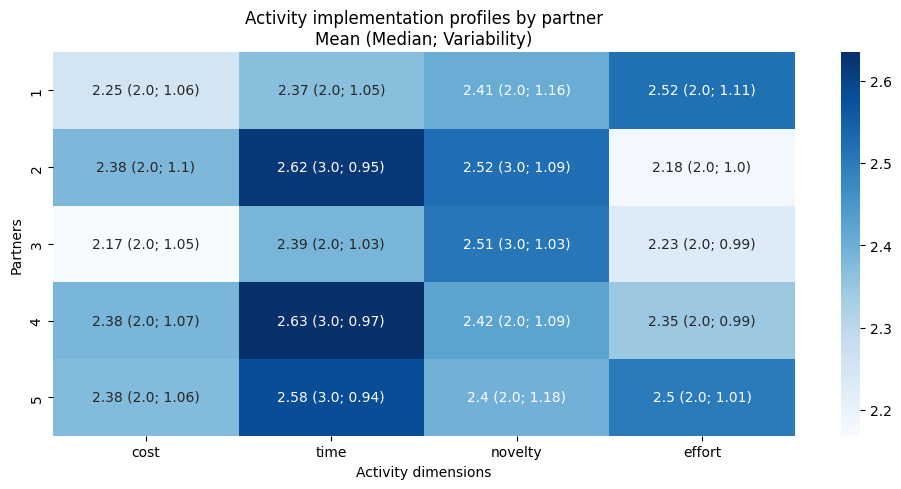

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create partner-level activity profiles with mean, median, and variability (std)
activity_partner_profile = (
    dataframes["3-Data_Simulation_Dataset__Activity_Partner"]
    .merge(
        dataframes["3-Data_Simulation_Dataset__Activity"],
        on="id_activity",
        how="left"
    )
    .groupby("id_partner")[["cost", "time", "novelty", "effort"]]
    .agg(["mean", "median", "std"])
)

# Extract mean, median, and variability values
mean_df = activity_partner_profile.xs("mean", level=1, axis=1)
median_df = activity_partner_profile.xs("median", level=1, axis=1)
std_df = activity_partner_profile.xs("std", level=1, axis=1)

# Create annotation labels showing mean (median; variability)
annot_df = mean_df.copy().astype(str)

for col in mean_df.columns:
    annot_df[col] = (
        mean_df[col].round(2).astype(str)
        + " ("
        + median_df[col].round(2).astype(str)
        + "; "
        + std_df[col].round(2).astype(str)
        + ")"
    )

# Generate heatmap using mean values for color intensity
plt.figure(figsize=(10, 5))

sns.heatmap(
    mean_df,
    annot=annot_df,
    fmt="",
    cmap="Blues"
)

plt.xlabel("Activity dimensions")
plt.ylabel("Partners")
plt.title("Activity implementation profiles by partner\nMean (Median; Variability)")

plt.tight_layout()
plt.show()

Partner-level activity profiles were examined to illustrate how the framework can summarize heterogeneous implementation characteristics across activity portfolios. The heatmap presents average activity-level scores for cost, time, novelty, and effort dimensions across partners, complemented by median values and variability measures to preserve the distributional characteristics of ordinal assessments. The results show relatively similar activity profiles across partners, with limited differences in central tendency and comparable levels of variability across dimensions. 

These patterns are not intended as comparative performance indicators or evidence of differences between partners, but rather as an illustration of how the framework organizes multidimensional implementation information while preserving contextual variation. The resulting profiles can support further contextual analysis of activity characteristics, implementation requirements, and potential areas for organizational learning.

## 3-Project-Level Insights

### Project Classification

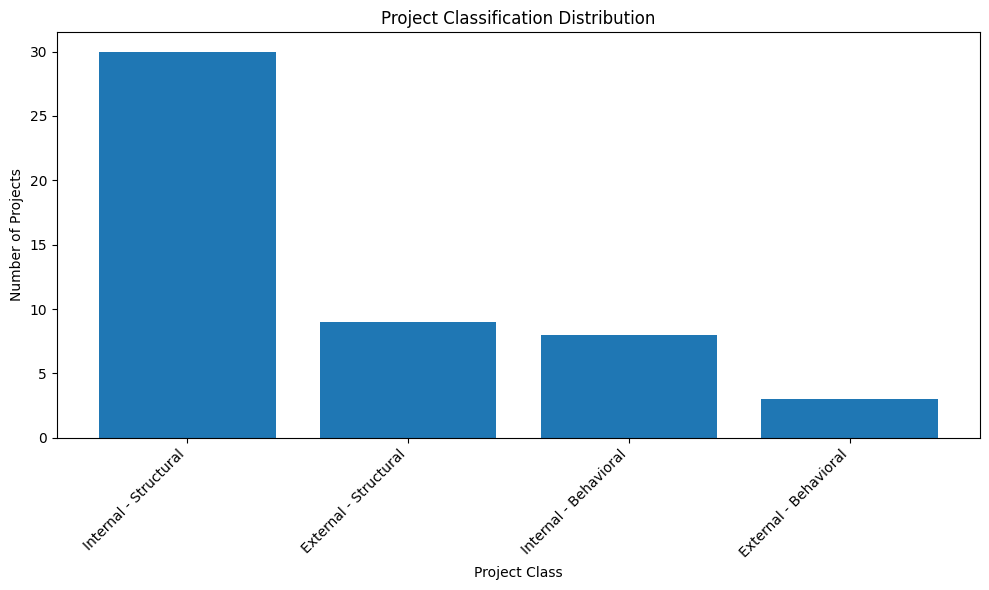

In [5]:
# Project Classification Distribution
# Count project classes
class_counts = (
    df_projects["project_class"]
    .value_counts()
    .reset_index()
)

class_counts.columns = ["project_class", "count"]

# Plot
plt.figure(figsize=(10,6))
plt.bar(class_counts["project_class"], class_counts["count"])

plt.title("Project Classification Distribution")
plt.xlabel("Project Class")
plt.ylabel("Number of Projects")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

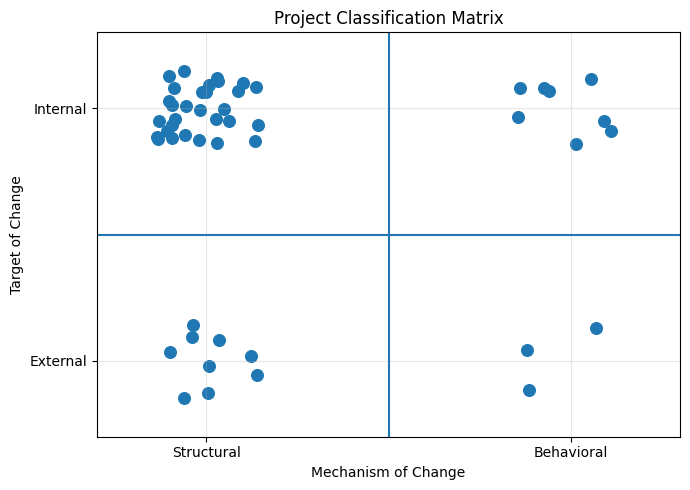

In [6]:
# Intervention Classification Matrix
import numpy as np

df_matrix = df_projects.copy()

# Create analytical dimensions
df_matrix["mechanism_of_change"] = df_matrix["project_class"].str.split(" - ").str[1]

df_matrix["target_of_change"] = (
    df_matrix["project_class"]
    .str.split(" - ").str[0]
    .map({
        "Internal": "Organizational",
        "External": "Beneficiary / Community"
    })
)

# Coordinates
df_matrix["x"] = df_matrix["mechanism_of_change"].map({
    "Structural": 0,
    "Behavioral": 1
})

df_matrix["y"] = df_matrix["target_of_change"].map({
    "Beneficiary / Community": 0,
    "Organizational": 1
})

# Jitter for project visualization
np.random.seed(42)

df_matrix["x_plot"] = df_matrix["x"] + np.random.uniform(-0.15, 0.15, len(df_matrix))
df_matrix["y_plot"] = df_matrix["y"] + np.random.uniform(-0.15, 0.15, len(df_matrix))


# Plot
plt.figure(figsize=(7,5))

plt.scatter(
    df_matrix["x_plot"],
    df_matrix["y_plot"],
    s=70
)

plt.axvline(0.5)
plt.axhline(0.5)

plt.xticks(
    [0,1],
    ["Structural", "Behavioral"]
)

plt.yticks(
    [0,1],
    ["External", "Internal"]
)

plt.xlabel("Mechanism of Change")
plt.ylabel("Target of Change")

plt.title("Project Classification Matrix")

plt.xlim(-0.3,1.3)
plt.ylim(-0.3,1.3)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

This classification shows that structural interventions represent the largest share of the portfolio. Internal–Structural projects are the most common category (30 projects), followed by External–Structural (9 projects), Internal–Behavioral (8 projects), and External–Behavioral (3 projects). Overall, the portfolio is mainly focused on systems, processes, and organizational tools rather than behavior-focused interventions.

A different pattern appears among behavioral projects, particularly Internal–Behavioral projects, which include several training-related activities. These projects show more variability in their evaluation outcomes, suggesting that their results may be more influenced by implementation conditions and participant engagement.

However, behavioral projects represent a smaller portion of the overall portfolio. Therefore, the focus is not on a broad redesign, but rather on targeted improvements in this area. Potential actions could include the development of a standardized training toolkit, ideally supported by volunteers or communication specialists, to encourage more consistent approaches across different contexts. In parallel, strengthening monitoring, evaluation, and accountability (MEAL) mechanisms for training activities could help improve the documentation of results, capture lessons learned, and provide better feedback for future training initiatives.

### Internal-Behavioral Projects

| Dimension                             | Observation                                                                       | Comparison Insight                            | Interpretation for Training Focus                                                                                                      |
| ------------------------------------- | --------------------------------------------------------------------------------- | --------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------- |
| Performance                           | 2.35 (highest among behavioral classes)                                           | Higher resource intensity (cost + time)       | Indicates higher cost and time requirements compared with the evaluation outcomes observed for this class                              |
| Use                                   | 2.32 (lowest structural-level use)                                                | Lower than structural classes                 | Suggests potential challenges related to the adoption and use of tools or processes                                                    |
| Results                               | 2.22 (lowest of all classes)                                                      | Below External–Structural (2.74)              | Suggests that activities within this category may require further analysis to better understand how they contribute to project results |
| Satisfaction                          | 2.51 (lowest overall)                                                             | Below structural classes                      | Suggests that participant experience and engagement may represent areas for further investigation                                      |
| Complexity (novelty + effort)         | 2.61 (highest)                                                                    | Higher than other classes                     | Indicates that these activities involve higher levels of adaptation and effort, which may require additional support and guidance      |
| Resilience (external risk resistance) | 3.70                                                                              | Slightly lower than External–Structural       | Suggests a moderate capacity to manage external challenges within the simulated portfolio                                              |
| Stability (internal risk resistance)  | 3.95 (lowest stability, but still relatively high on scale where higher = better) | Below External–Structural (4.89)              | Suggests potential opportunities to strengthen internal processes and standardization                                                  |
| Robustness check (Median)             | Median values closely align with means across most indicators                     | Indicates limited influence of extreme values | Suggests that the observed patterns are relatively consistent within the simulated dataset                                             |


### Characteristics of Projects with Higher Aggregated Evaluation Profiles

To complement the project-class analysis, projects with higher aggregated evaluation profiles were examined in greater detail to explore whether they share common organizational characteristics or implementation patterns. Rather than focusing on individual rankings, the objective was to identify potential patterns that could inform future program planning and resource allocation.

In [7]:
# Characteristics of projects with highest aggregated evaluation profiles
# Project-level analytical dataset
df_project = dataframes["6-Data_Project_Dataset__Project_FE"].copy()

# Project titles
df_titles = (
    dataframes["3-Data_Simulation_Dataset__Project"]
    [["id_project", "project_title"]]
)

# Reverse-code operational dimensions
df_eval = df_project.copy()

df_eval["performance_mean_adj"] = (
    df_eval["performance_mean"].max()
    - df_eval["performance_mean"]
)

df_eval["complexity_mean_adj"] = (
    df_eval["complexity_mean"].max()
    - df_eval["complexity_mean"]
)

# Overall score
score_cols = [
    "performance_mean_adj",
    "complexity_mean_adj",
    "use_mean",
    "quality_mean",
    "reach_mean",
    "results_mean",
    "satisfaction_mean",
    "alignment_mean",
    "durability_mean",
    "resilience_mean",
    "collaboration_mean",
    "stability_mean"
]

df_eval["overall_score"] = df_eval[score_cols].mean(axis=1)

# Top 10 (highest aggregated evaluation profiles)
top10_projects = (
    df_eval
    .merge(df_titles, on="id_project", how="left")
    .sort_values("overall_score", ascending=False)
    .head(10)
)

# Final table
top10_projects = top10_projects[
    [
        "project_title",
        "project_type",
        "project_class",
        "overall_score",
        "n_activities",
        "education",
        "previous_mandates"
    ]
].round({"overall_score": 3})

display(top10_projects)

,project_title,project_type,project_class,overall_score,n_activities,education,previous_mandates
31,Operations Management Toolkit,Tools,External - Structural,3.100,5,Master's Degree and above,0
21,Environmental Policy,Policy,Internal - Structural,3.025,4,Bachelor's Degree,2
41,Safeguarding Policy,Policy,Internal - Structural,2.988,2,Master's Degree and above,0
1,Gender Baseline Assessment,Assessment,Internal - Structural,2.985,4,Master's Degree and above,0
15,Gender Policy,Policy,Internal - Structural,2.950,5,Bachelor's Degree,3 or more
43,Community Perception Study,Study,External - Structural,2.939,5,Master's Degree and above,3 or more
6,Development of a Change Management Toolkit,Tools,Internal - Structural,2.931,4,Bachelor's Degree,3 or more
0,Analysis of Gender Inequality in the Community,Analysis,External - Structural,2.925,5,Master's Degree and above,0
27,Communication and Stakeholder Engagement Toolkit,Tools,External - Structural,2.925,5,Bachelor's Degree,3 or more
2,Nutrition and Health Capacity Building Program,Capacity Building,External - Behavioral,2.906,3,Master's Degree and above,1


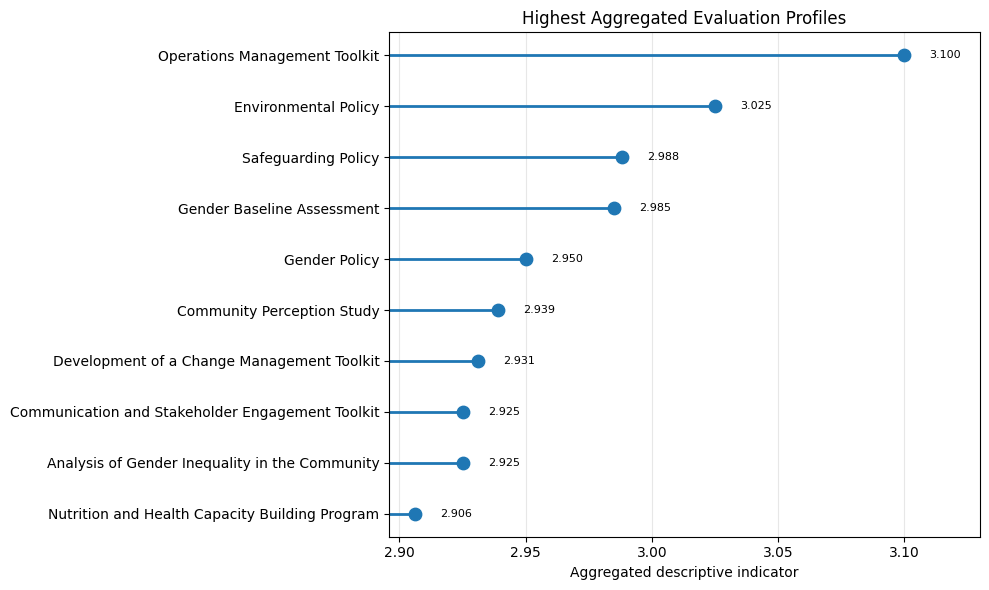

In [8]:
# Lollipop chart of the highest aggregated evaluation profiles

plot_df = (
    top10_projects
    .sort_values("overall_score")
    .copy()
)

plt.figure(figsize=(10,6))

# Horizontal lines
plt.hlines(
    y=plot_df["project_title"],
    xmin=plot_df["overall_score"].min() - 0.01,
    xmax=plot_df["overall_score"],
    linewidth=2
)

# Points
plt.scatter(
    plot_df["overall_score"],
    plot_df["project_title"],
    s=80,
    zorder=3
)

# Display score next to each point
for _, row in plot_df.iterrows():
    plt.text(
        row["overall_score"] + 0.010,
        row["project_title"],
        f"{row['overall_score']:.3f}",
        va="center",
        fontsize=8
    )

plt.xlabel("Aggregated descriptive indicator")
plt.ylabel("")
plt.title("Highest Aggregated Evaluation Profiles")

plt.xlim(
    plot_df["overall_score"].min() - 0.01,
    plot_df["overall_score"].max() + 0.03
)

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

The highest aggregated evaluation profiles were mainly observed among projects implemented with a small number of partners, especially Partner 3 and Partner 1, which together accounted for a large share of these initiatives. This suggests that partner-related characteristics may warrant further examination, although no general conclusion can be drawn from this simulated dataset.

From the volunteer perspective, previous mandate experience did not show a clear pattern. Projects with higher aggregated evaluation profiles included both experienced and less experienced volunteers, suggesting that individual experience alone did not explain differences within this dataset.

Most of these projects were structural interventions (Internal and External – Structural), mainly focused on policies, tools, and organizational systems rather than direct field activities.

Overall, these results suggest further examination of selected projects to better understand contextual factors, implementation characteristics, and practices observed within higher aggregated evaluation profiles. Documenting selected cases could support organizational learning by identifying practices and conditions that may be explored in future programs.

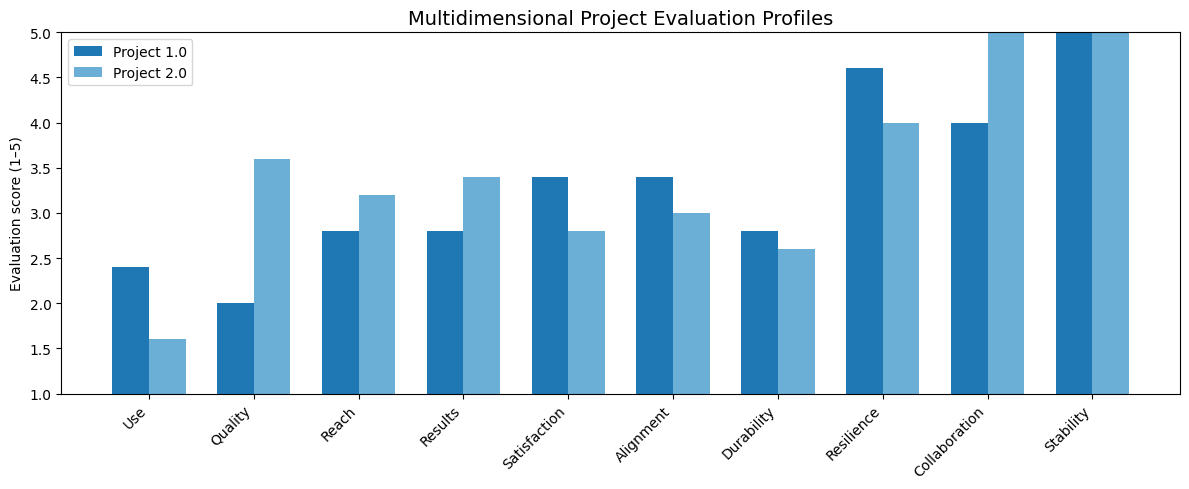

In [9]:
# Select 2 projects for illustration
selected_projects = [1, 2]

# Project-level evaluation dimensions
dimensions = [
    "use_mean",
    "quality_mean",
    "reach_mean",
    "results_mean",
    "satisfaction_mean",
    "alignment_mean",
    "durability_mean",
    "resilience_mean",
    "collaboration_mean",
    "stability_mean"
]

labels = [
    "Use",
    "Quality",
    "Reach",
    "Results",
    "Satisfaction",
    "Alignment",
    "Durability",
    "Resilience",
    "Collaboration",
    "Stability"
]

# Extract selected projects
hist_data = (
    dataframes["3-Data_Simulation_Dataset__Project"]
    .loc[
        lambda x: x["id_project"].isin(selected_projects),
        ["id_project"] + dimensions
    ]
)

# Prepare grouped bar chart
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))

# Same blue as Matplotlib default + lighter shade
blue_colors = ["#1f77b4", "#6baed6"]

for i, (_, row) in enumerate(hist_data.iterrows()):

    ax.bar(
        x + (i - 0.5) * width,
        row[dimensions],
        width,
        label=f"Project {row['id_project']}",
        color=blue_colors[i]
    )

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(
    labels,
    rotation=45,
    ha="right"
)

ax.set_ylim(1, 5)

ax.set_ylabel("Evaluation score (1–5)")

ax.set_title(
    "Multidimensional Project Evaluation Profiles",
    fontsize=14
)

ax.legend()

plt.tight_layout()
plt.show()

This example illustrates how the framework generates multidimensional project-level evaluation profiles using two illustrative reconstructed interventions. Rather than reducing evaluation results to a single performance score, the framework preserves differences across evaluation dimensions, allowing each intervention to be interpreted according to its specific contribution profile. The profiles highlight how projects may present different combinations of strengths and limitations across dimensions such as use, results, alignment, durability, and collaboration. These visualizations are intended to demonstrate the analytical structure generated by the framework and do not represent comparative rankings or performance assessments between projects.

### Feature Importance Comparison

**Normally, the results presented in this section would not be used for decision-making, given the exploratory nature of the dataset, its small sample size, and the limited predictive performance of the models. Both approaches show limited predictive capability, meaning that they do not provide reliable predictions of project-level evaluation outcomes within the simulated dataset.**

**However, this section is included as a proof-of-concept to illustrate the type of analytical insights that the framework could generate when applied to richer and more complete datasets. The objective is not to draw definitive conclusions, but rather to demonstrate the potential value of these approaches in future real-world implementations.**

Two different modelling approaches are used to explore relationships between project characteristics and evaluation outcomes. The first, linear regression, captures simple associations between variables and outcomes. The second, random forest, identifies more complex patterns where variables may interact under different combinations of conditions.

By comparing both approaches, we can distinguish between:

* dimensions that appear consistently important across different modelling approaches; and
* patterns that may depend on combinations of variables and contextual conditions.

This comparison provides an illustration of how the framework could extend beyond descriptive analysis toward more advanced decision-support approaches as additional data become available.

| Feature            | Linear Regression (coef) | Random Forest (importance) | Interpretation                                                                                 |
| ------------------ | -----------------------: | -------------------------: | ---------------------------------------------------------------------------------------------- |
| durability_mean    |                   +0.178 |                      0.137 | Shows a relatively consistent positive association across both exploratory models              |
| collaboration_mean |                   +0.145 |                      0.095 | Shows a positive association across both models, with a stronger signal in the linear approach |
| resilience_mean    |                   +0.133 |                      0.105 | Shows a consistent positive association across both modelling approaches                       |
| performance_mean   |                   +0.121 |                      0.067 | Shows a stronger association in the linear model and a weaker signal in the non-linear model   |
| use_mean           |                   -0.010 |                      0.150 | Shows a stronger signal in the Random Forest model, suggesting potential non-linear patterns   |
| alignment_mean     |                   -0.030 |                      0.116 | Shows limited linear association but a stronger signal when interactions are considered        |
| satisfaction_mean  |                   -0.083 |                      0.109 | Shows different patterns across models, suggesting possible context-dependent relationships    |
| n_activities       |                   +0.097 |                      0.064 | Shows a moderate structural signal with limited predictive contribution                        |
| reach_mean         |                   -0.067 |                      0.052 | Shows a weak and inconsistent signal across models                                             |
| stability_mean     |                   -0.060 |                      0.020 | Shows limited importance across both models                                                    |
| quality_mean       |                   +0.043 |                      0.046 | Shows a small but relatively consistent signal across models                                   |
| complexity_mean    |                   +0.030 |                      0.038 | Shows a weak signal across both models                                                         |


The three dimensions showing the most consistent associations with project-level evaluation outcomes across both modelling approaches are durability, collaboration, and resilience. These dimensions appear in both the linear regression and random forest models, suggesting that they represent important patterns identified across different analytical approaches rather than model-specific signals. Within the simulated dataset, stronger evaluation outcomes are associated with projects showing higher levels of these dimensions.

**Durability** refers to the extent to which conditions supporting sustainability are incorporated into project design and implementation. This includes elements such as clearer planning, better definition of expected outcomes, and more structured follow-up mechanisms. These aspects may contribute to maintaining project continuity and should be further examined in future applications using real-world data.

**Resilience** relates to the ability of projects to anticipate and manage risks, particularly external risks within this framework. This includes stronger risk identification processes at both project and organizational levels, as well as monitoring mechanisms to support early identification of potential challenges.

**Collaboration** relates to how roles, responsibilities, and interactions are structured across stakeholders. Potential areas for strengthening collaboration include clearer role definitions, coordination tools, standardized templates, and structured communication practices. In addition, a basic communication and onboarding toolkit at the beginning of projects or new partner collaborations could be explored as a way to support alignment and coordination.


## 4-Program-Level Insights

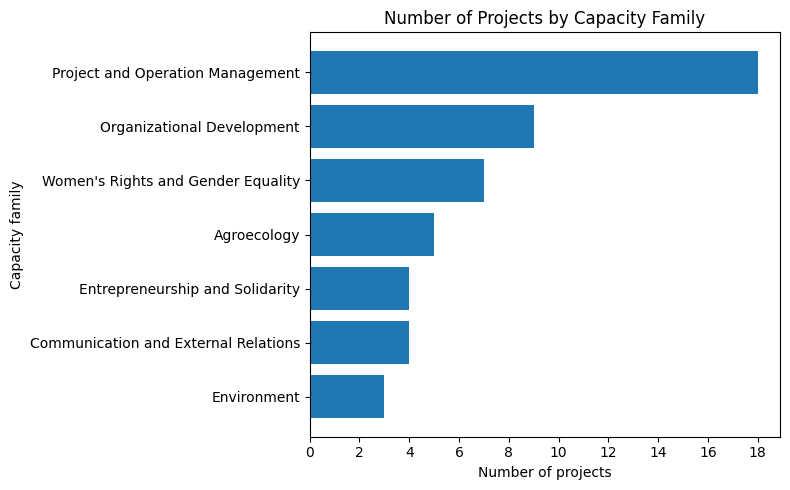

In [10]:
from matplotlib.ticker import MaxNLocator

# Link projects to capacity families through mandate relationships
project_capacity = (
    dataframes["3-Data_Simulation_Dataset__Project"][["id_project", "id_mandate"]]
    .merge(
        dataframes["3-Data_Simulation_Dataset__Mandate_Capacity"],
        on="id_mandate",
        how="left"
    )
    .merge(
        dataframes["3-Data_Simulation_Dataset__Capacity"],
        on="id_capacity",
        how="left"
    )
)

# Count unique projects by capacity family
projects_by_capacity = (
    project_capacity[["id_project", "capacity_name"]]
    .drop_duplicates()
    .groupby("capacity_name")
    .size()
    .reset_index(name="n_projects")
    .sort_values(
        "n_projects",
        ascending=True
    )
)

# Horizontal bar chart
plt.figure(figsize=(8,5))

plt.barh(
    projects_by_capacity["capacity_name"],
    projects_by_capacity["n_projects"]
)

plt.xlabel("Number of projects")
plt.ylabel("Capacity family")
plt.title("Number of Projects by Capacity Family")

plt.gca().xaxis.set_major_locator(
    MaxNLocator(integer=True)
)

plt.tight_layout()
plt.show()

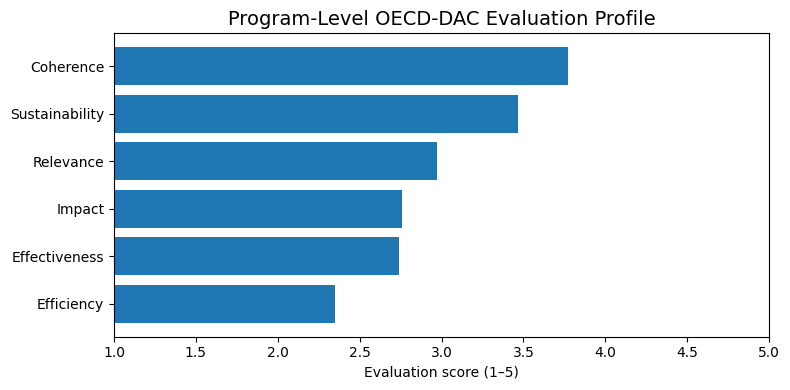

In [11]:
# Program-level OECD-DAC profile

oecd_scores = {
    "Efficiency": (
        dataframes["3-Data_Simulation_Dataset__Activity"][
            ["cost", "time", "novelty", "effort"]
        ]
        .mean()
        .mean()
    ),
    "Effectiveness": (
        df_projects[["use_mean", "quality_mean"]]
        .mean()
        .mean()
    ),
    "Impact": (
        df_projects[["reach_mean", "results_mean"]]
        .mean()
        .mean()
    ),
    "Relevance": (
        df_projects[["satisfaction_mean", "alignment_mean"]]
        .mean()
        .mean()
    ),
    "Sustainability": (
        df_projects[["durability_mean", "resilience_mean"]]
        .mean()
        .mean()
    ),
    "Coherence": (
        df_projects[["collaboration_mean", "stability_mean"]]
        .mean()
        .mean()
    )
}

labels = list(oecd_scores.keys())
values = list(oecd_scores.values())

# Horizontal bar chart
fig, ax = plt.subplots(figsize=(8, 4))

ax.barh(
    labels,
    values,
    color="#1f77b4"
)

# Formatting
ax.set_xlim(1, 5)

ax.set_xlabel(
    "Evaluation score (1–5)"
)

ax.set_title(
    "Program-Level OECD-DAC Evaluation Profile",
    fontsize=14
)

plt.tight_layout()
plt.show()

Program-level analyses further illustrate how the framework can summarize portfolio characteristics across multiple organizational perspectives. The distribution of projects across capacity families shows that the reconstructed portfolio spans several organizational domains, with a stronger concentration in Project and Operation Management (18 projects) and Organizational Development (9 projects), while other capacity families are represented by smaller numbers of projects. This type of overview can support organizations in examining the balance of their intervention portfolio, identifying areas of concentration, and informing future planning or resource allocation.

The aggregated OECD-DAC profile demonstrates how evaluation information can also be synthesized at the program level. Within the simulated portfolio, coherence (3.77) and sustainability (3.47) show the highest average scores, whereas efficiency (2.35) presents the lowest average value. Rather than representing definitive strengths or weaknesses, these aggregated profiles illustrate how the framework can identify dimensions that may warrant further examination, support longitudinal monitoring of program performance, and facilitate comparisons across portfolios or evaluation cycles as additional empirical data become available.

## 5-Insights Summary with Credibility-Level

| Recommendation Area                                       | Specific Action                                                                                                                                  | Linked Insight                                                                                 | Credibility Level | Evidence Strength                | Priority |
| --------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------ | ---------------------------------------------------------------------------------------------- | --------------- | -------------------------------- | -------- |
| Explore AI-assisted efficiency tools                      | Explore AI tools to support repetitive activities and improve workflow efficiency                                                                | Derived from effort-heavy activity patterns                                                    | 1.7–2.9         | Limited documentary evidence     | LOW      |
| Improve design of high-effort and high-novelty activities | Identify activities with higher novelty and effort scores, review deliverables, and strengthen activity structure                                | Cluster analysis of activity patterns (novelty + effort)                                       | 2.9–3.2         | Moderate documentary evidence    | MEDIUM   |
| Standardize document-based activities                     | Use templates, reusable content, structured guidance, and AI-assisted tools for Document Writing, Document Analysis, and Presentation activities | High concentration of document-based activities (~60% of activities)                           | 3.0–3.3         | Moderate documentary evidence    | MEDIUM   |
| Develop partner-level learning system                     | Document selected projects by partner and identify recurring practices and contextual factors                                                    | Observed concentration of top-ranked projects among selected partners                          | 3.3–3.6         | Strong documentary evidence      | MEDIUM   |
| Reinforce collaboration structures                        | Define roles and responsibilities, use coordination tools, structured meetings, and onboarding resources for new partners                        | Collaboration showing consistent association with evaluation outcomes                          | 3.42            | Strong documentary evidence      | MEDIUM   |
| Strengthen project durability                             | Reinforce sustainability considerations from the beginning, including planning and structured follow-up mechanisms                               | Durability showing a consistent association with evaluation outcomes across exploratory models | 3.54            | Strong documentary evidence      | HIGH     |
| Improve resilience through risk management                | Strengthen risk identification and monitoring processes at project and organizational levels                                                     | Resilience showing a strong association with evaluation outcomes within exploratory models     | 4.08            | Very strong documentary evidence | HIGH     |


Overall, the recommendations can be organized into a priority structure based on their credibility levels:

* High-priority actions focus on strengthening project resilience and durability, as these dimensions show the strongest documentary support and the most consistent associations with evaluation outcomes across the exploratory analyses. However, these results come from a simulation exercise, and the models did not demonstrate strong predictive capability. The purpose is to illustrate the potential value of this approach when applied to richer real-world datasets.

* Medium-priority actions relate to strengthening collaboration structures, standardizing document-based activities, and improving the design of high-effort or high-novelty activities. These areas are supported by moderate levels of credibility within the simulated dataset.

* Lower-priority actions, such as exploring AI-assisted efficiency tools, remain more exploratory in nature and should be considered as potential opportunities for future validation.

This prioritization framework does not rely solely on evidence strength, but incorporates it as one of several inputs to support more balanced and context-aware decision-making.


## 6-Documentary Evidence Insights

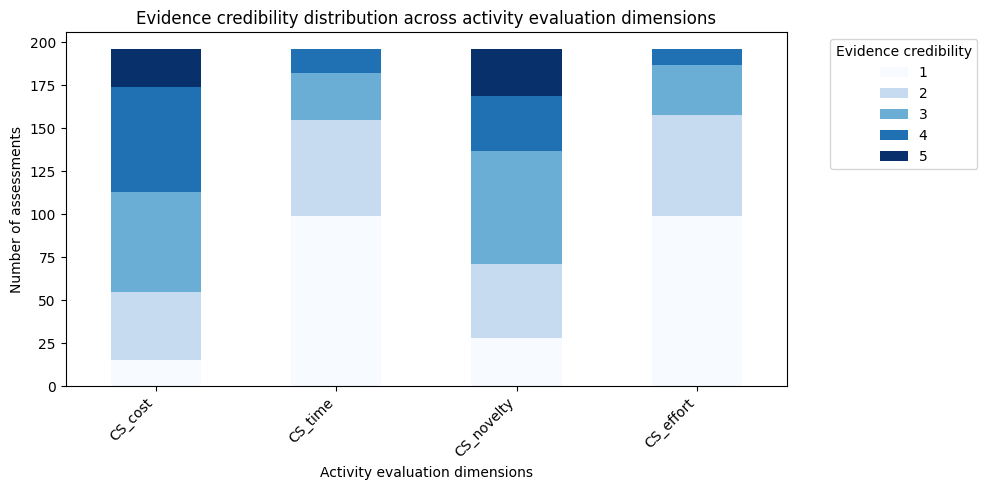

In [12]:
# Activity-level evidence credibility distribution
activity_profile = (
    df_activities[
        ["CS_cost", "CS_time", "CS_novelty", "CS_effort"]
    ]
    .apply(pd.Series.value_counts)
    .fillna(0)
    .sort_index()
    .T
)

activity_profile.plot(
    kind="bar",
    stacked=True,
    figsize=(10,5),
    colormap="Blues"
)

plt.xlabel("Activity evaluation dimensions")
plt.ylabel("Number of assessments")
plt.title("Evidence credibility distribution across activity evaluation dimensions")
plt.xticks(rotation=45, ha="right")

plt.legend(
    title="Evidence credibility",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

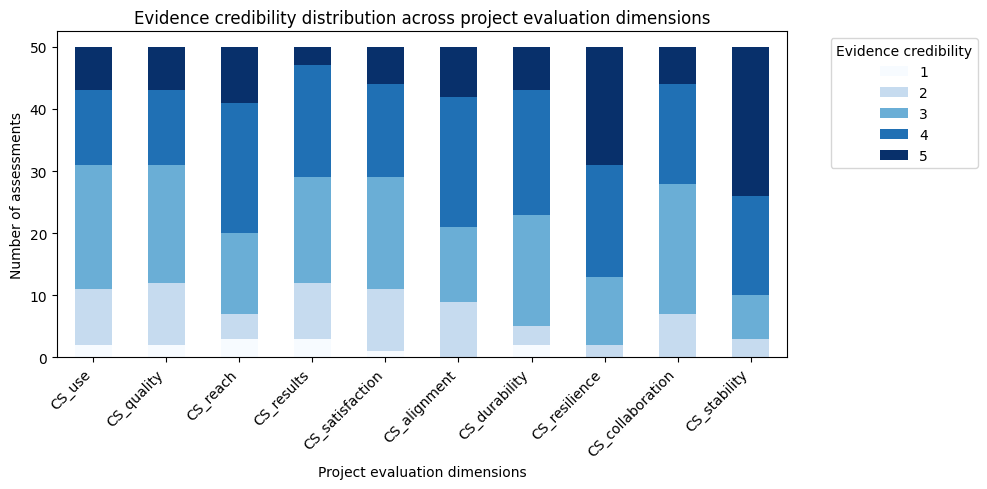

In [13]:
# Project-level evidence credibility distribution
project_profile = (
    df_projects[
        ["CS_use", "CS_quality", "CS_reach", "CS_results",
         "CS_satisfaction", "CS_alignment", "CS_durability",
         "CS_resilience", "CS_collaboration", "CS_stability"]
    ]
    .apply(pd.Series.value_counts)
    .fillna(0)
    .sort_index()
    .T
)

project_profile.plot(
    kind="bar",
    stacked=True,
    figsize=(10,5),
    colormap="Blues"
)

plt.xlabel("Project evaluation dimensions")
plt.ylabel("Number of assessments")
plt.title("Evidence credibility distribution across project evaluation dimensions")
plt.xticks(rotation=45, ha="right")

plt.legend(
    title="Evidence credibility",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

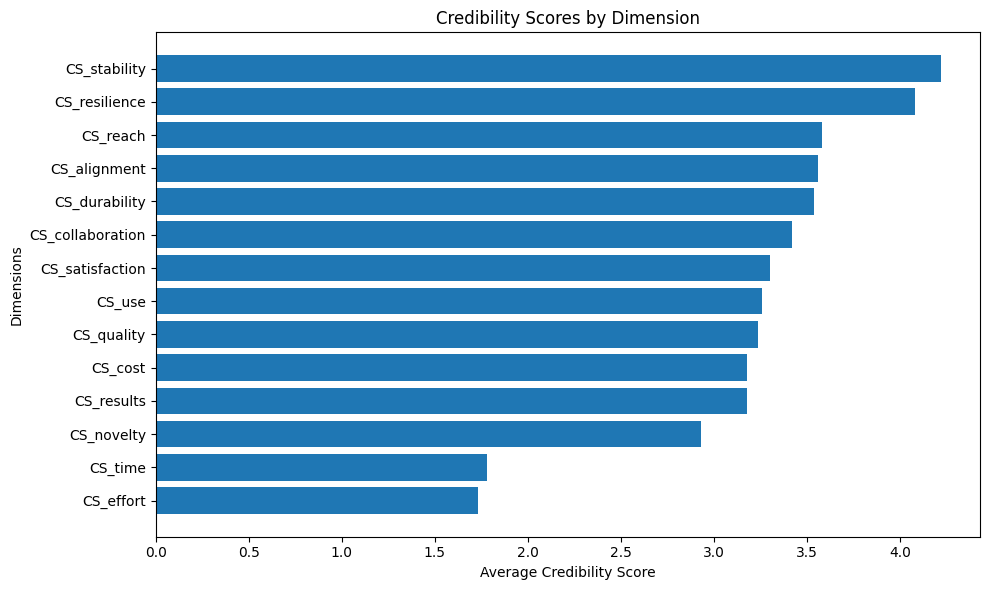

In [14]:
# Project-level credibility scores
project_cs = {
    "CS_use": 3.26,
    "CS_quality": 3.24,
    "CS_reach": 3.58,
    "CS_results": 3.18,
    "CS_satisfaction": 3.30,
    "CS_alignment": 3.56,
    "CS_durability": 3.54,
    "CS_resilience": 4.08,
    "CS_collaboration": 3.42,
    "CS_stability": 4.22
}

# Activity-level credibility scores
activity_cs = {
    "CS_cost": 3.18,
    "CS_time": 1.78,
    "CS_novelty": 2.93,
    "CS_effort": 1.73
}

# Combine both levels
all_cs = {**project_cs, **activity_cs}

df_cs = pd.DataFrame(list(all_cs.items()), columns=["dimension", "score"])

# Sort ascending
df_cs = df_cs.sort_values("score", ascending=True)

# Plot
plt.figure(figsize=(10,6))
plt.barh(df_cs["dimension"], df_cs["score"])

plt.title("Credibility Scores by Dimension")
plt.xlabel("Average Credibility Score")
plt.ylabel("Dimensions")

plt.tight_layout()
plt.show()

The credibility analysis highlights differences in the strength of available documentation across dimensions. Execution-level variables, particularly time (CS_time = 1.78) and effort (CS_effort = 1.73), show the lowest credibility levels, indicating that these aspects are less consistently documented within the simulated evaluation structure.

In contrast, dimensions such as resilience, stability, and collaboration show higher credibility levels, suggesting that information related to project and organizational characteristics is more consistently captured. This difference indicates that while higher-level dimensions are better supported by available evidence, some operational-level variables remain less documented.

As a result, improving the measurement and documentation of time and effort at the activity level represents a potential area for strengthening future data collection and expanding the analytical capabilities of the framework.


| Recommendation Area                             | Specific Action                                                                                      | Linked Insight                                                                                                                                                 |
| ----------------------------------------------- | ---------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Improve measurement of activity time and effort | Introduce a simple and standardized method to capture and document time and effort for each activity | Low credibility levels for CS_time (1.78) and CS_effort (1.73), indicating that execution-level information is less consistently documented within the framework |


## 7-Cross-Level Analytical Synthesis

| Analytical Layer                    | Key Finding                                                                                                                      | Converging Evidence                                                       | Decision Implication                                                                                  |
| ----------------------------------- | -------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------- | ----------------------------------------------------------------------------------------------------- |
| Activity Level                      | High-effort and high-novelty activities are associated with higher-ranked projects based on evaluation outcomes                  | Cluster analysis (novelty/effort patterns)                                | Focus on improving activity design and structure rather than directly reducing cost                   |
| Project Level                       | Structural interventions (tools, policies, systems) are more frequently observed among top-ranked projects                       | Top 10 project analysis                                                   | Consider prioritizing structural project design while further examining behavioral interventions      |
| Machine Learning (Exploratory)      | Durability, collaboration, and resilience show the most consistent associations across exploratory models                        | Linear regression + Random Forest feature importance                      | Focus on dimensions showing consistent signals rather than isolated model results                     |
| Evidence Credibility (Project Level)  | Project-level structural dimensions show higher credibility, while some execution-level variables are less consistently documented | CS resilience (4.08), durability (3.54), vs CS time (1.78), effort (1.73) | Give greater consideration to higher-credibility dimensions while maintaining a balanced interpretation |
| Evidence Credibility (Activity Level) | Time and effort measurements show lower credibility levels within the activity-level data structure                                | Low CS_time and CS_effort                                                 | Improve operational data capture to support future analytical applications                            |


## 8-Data Size and Completeness Sensitivity Analysis

This section evaluates the robustness of the main exploratory findings by progressively reducing dataset size and introducing controlled missingness. The objective is to assess the stability of project rankings, the consistency of identified associations with evaluation outcomes, and the impact of data limitations on the analytical results.

### Data Availability

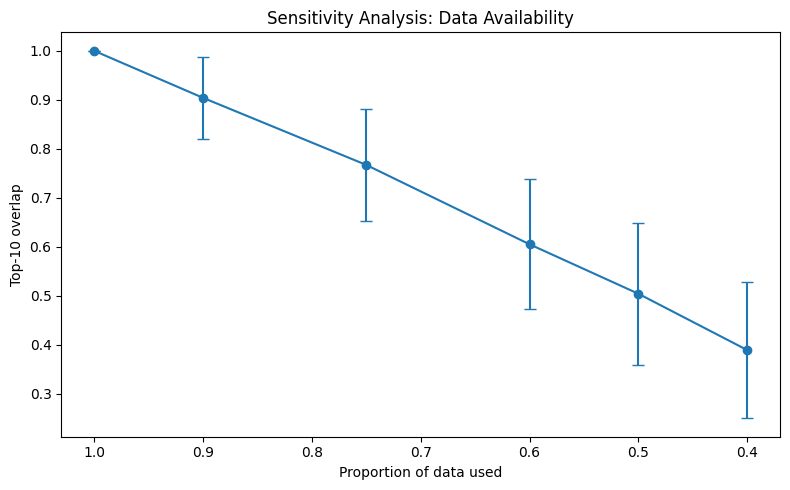

,data_ratio,n_projects,top10_overlap_mean,top10_overlap_sd,importance_variability
0,1.00,50,1.000,0.000000,0.009732
1,0.90,45,0.904,0.083570,0.022492
2,0.75,37,0.767,0.114066,0.035905
3,0.60,30,0.605,0.132947,0.048704
4,0.50,25,0.504,0.144859,0.054501
5,0.40,20,0.389,0.139208,0.064492


In [15]:
# Data availability sensitivity
from sklearn.ensemble import RandomForestRegressor

df = df_eval

target = "overall_score"

features = [
    "performance_mean_adj",
    "complexity_mean_adj",
    "use_mean",
    "quality_mean",
    "reach_mean",
    "results_mean",
    "satisfaction_mean",
    "alignment_mean",
    "durability_mean",
    "resilience_mean",
    "collaboration_mean",
    "stability_mean"
]

baseline_top10 = set(
    df.sort_values(target, ascending=False)
      .head(10)["id_project"]
)

ratios = [1.0, 0.9, 0.75, 0.6, 0.5, 0.4]
n_runs = 100

results = []

for r in ratios:

    overlaps = []
    importances = []

    for seed in range(n_runs):

        sample = df.sample(frac=r, random_state=seed)

        if len(sample) < 20:
            continue

        top10 = set(
            sample.sort_values(target, ascending=False)
                  .head(10)["id_project"]
        )

        overlaps.append(len(baseline_top10 & top10) / 10)

        rf = RandomForestRegressor(
            n_estimators=100,
            random_state=seed
        )

        rf.fit(sample[features], sample[target])

        importances.append(rf.feature_importances_)

    importances = np.array(importances)

    results.append({
        "data_ratio": r,
        "n_projects": int(len(df) * r),
        "top10_overlap_mean": np.mean(overlaps),
        "top10_overlap_sd": np.std(overlaps),
        "importance_variability": importances.std(axis=0).mean()
    })

data_availability_results = pd.DataFrame(results)

plt.figure(figsize=(8,5))

plt.errorbar(
    data_availability_results["data_ratio"],
    data_availability_results["top10_overlap_mean"],
    yerr=data_availability_results["top10_overlap_sd"],
    marker="o",
    capsize=4
)

plt.gca().invert_xaxis()

plt.xlabel("Proportion of data used")
plt.ylabel("Top-10 overlap")
plt.title("Sensitivity Analysis: Data Availability")

plt.tight_layout()
plt.show()

data_availability_results

The results show a gradual decline in ranking stability as data availability decreases. With 90% of the data, the top-10 ranking remains consistent, while stability progressively decreases as fewer projects are available. Below approximately 60% data availability, the rankings become more sensitive to the sampled projects.

In contrast, feature importance shows relatively limited variation across the tested scenarios, suggesting that the main dimensions identified by the exploratory model remain relatively consistent within the simulated dataset. Overall, these results indicate that the framework maintains a degree of stability under moderate reductions in data availability, while larger reductions increase uncertainty in project ranking.

### Data Completeness

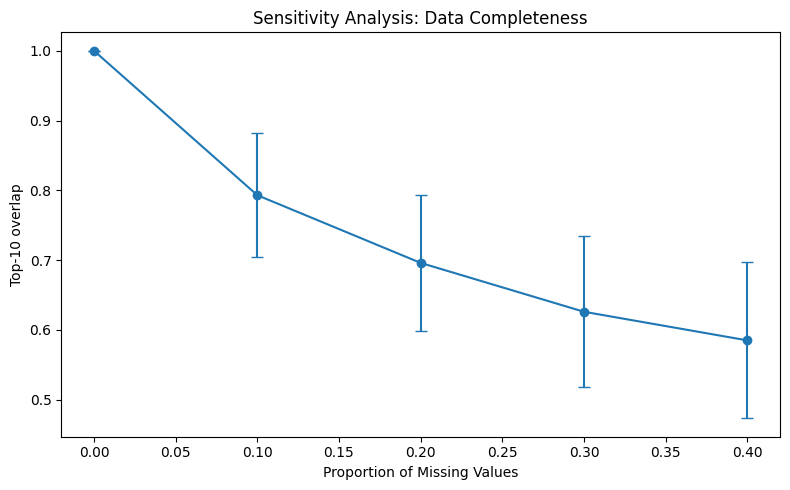

,missing_rate,top10_overlap_mean,top10_overlap_sd
0,0.0,1.000,0.000000
1,0.1,0.793,0.088606
2,0.2,0.696,0.097898
3,0.3,0.626,0.108277
4,0.4,0.585,0.111692


In [16]:
# Data completeness sensitivity
missing_levels = [0.0, 0.1, 0.2, 0.3, 0.4]

results = []

for m in missing_levels:

    overlaps = []

    for seed in range(n_runs):

        rng = np.random.default_rng(seed)

        sample = df.copy()

        for col in features:
            mask = rng.random(len(sample)) < m
            sample.loc[mask, col] = np.nan

        sample[features] = sample[features].fillna(
            sample[features].median()
        )

        sample[target] = sample[score_cols].mean(axis=1)

        top10 = set(
            sample.sort_values(target, ascending=False)
                  .head(10)["id_project"]
        )

        overlaps.append(len(baseline_top10 & top10) / 10)

    results.append({
        "missing_rate": m,
        "top10_overlap_mean": np.mean(overlaps),
        "top10_overlap_sd": np.std(overlaps)
    })

data_completeness_results = pd.DataFrame(results)

plt.figure(figsize=(8,5))

plt.errorbar(
    data_completeness_results["missing_rate"],
    data_completeness_results["top10_overlap_mean"],
    yerr=data_completeness_results["top10_overlap_sd"],
    marker="o",
    capsize=4
)

plt.xlabel("Proportion of Missing Values")
plt.ylabel("Top-10 overlap")
plt.title("Sensitivity Analysis: Data Completeness")

plt.tight_layout()
plt.show()

data_completeness_results

The results suggest that the framework maintains a degree of stability under small amounts of missing data. At 10% missingness, most of the top-ranked projects remain consistent, while ranking stability gradually decreases as more information becomes unavailable.

Overall, the results indicate that higher levels of missing data increase uncertainty in project rankings within the simulated dataset. These findings highlight the importance of maintaining data completeness and carefully managing missing information in future real-world applications.